# Análise dos dados

Exploração das duas bases públicas que alimentam o sistema de priorização da
fiscalização ambiental, e o ranking produzido a partir delas.

1. **SiCAR** — imóveis rurais e suas geometrias.
2. **MapBiomas Alerta** — alertas de desmatamento cruzados com o imóvel.
3. **Priorização** — o pipeline de ML do repositório.

As credenciais do MapBiomas vêm dos *Secrets* do Colab (ícone de chave):
`MAPBIOMAS_USERNAME` e `MAPBIOMAS_PASSWORD`.

# Sicar

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
!wget -q https://raw.githubusercontent.com/Pedrinhonitz/planejamento-gestao-projetos/refs/heads/main/notebooks/hooks/http_sicar_hook.py
from http_sicar_hook import HttpSicarHook

In [ ]:
sicar = HttpSicarHook()

In [ ]:
data = sicar.get_sicar_data("sc", )

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'geoserver.car.gov.br'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [ ]:
df = gpd.GeoDataFrame(
    data,
    geometry=[wkt.loads(g) if g else None for g in (r["geometry"] for r in data)],
    crs="EPSG:4326",
)

In [ ]:
df

,cod_imovel,status_imovel,dat_criacao,area,condicao,uf,municipio,cod_municipio_ibge,m_fiscal,tipo_imovel,geometry,total_features,number_matched,number_returned,start_index,page,remaining,is_pagination
0,SC-4210803-BC127B0EC8DB49AC9D46D723286241A2,PE,2014-05-07T19:02:02.915Z,7.5340,"Analisado, aguardando atendimento a notificação",sc,Meleiro,4210803,0.4186,IRU,"MULTIPOLYGON (((-49.65525 -28.79345, -49.65517...",431847,431847,1000,0,0,430847,False
1,SC-4207502-E675C23ECEB149F091AD009E3B23DC01,CA,2014-05-09T17:30:08.423Z,0.2116,Cancelado por decisão administrativa,sc,Indaial,4207502,0.0176,IRU,"MULTIPOLYGON (((-49.22587 -26.89228, -49.2256 ...",431847,431847,1000,0,0,430847,False
2,SC-4216800-378EFB28BAB94A54BA4663998EF9E5E4,AT,2014-05-09T18:16:37.725Z,27.9789,Em análise,sc,São José do Cerrito,4216800,1.3989,IRU,"MULTIPOLYGON (((-50.62951 -27.70557, -50.62983...",431847,431847,1000,0,0,430847,False
3,SC-4210803-DBAE1CCF8EF9479E92CA31B04C5843F1,AT,2014-05-09T22:29:53.413Z,3.0010,"Analisado, aguardando atendimento a notificação",sc,Meleiro,4210803,0.1667,IRU,"MULTIPOLYGON (((-49.6647 -28.79335, -49.66473 ...",431847,431847,1000,0,0,430847,False
4,SC-4216602-A78BA270EF1342F8A6C6F2060B51FA72,AT,2014-05-11T23:51:42.657Z,13.1563,Em análise,sc,São José,4216602,1.0964,IRU,"MULTIPOLYGON (((-48.66266 -27.59013, -48.66151...",431847,431847,1000,0,0,430847,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,SC-4208807-26987BDE762F44308680E8A81B6BD9CA,AT,2014-07-25T13:58:27.477Z,12.5772,Aguardando análise,sc,Jaguaruna,4208807,0.6289,IRU,"MULTIPOLYGON (((-49.07402 -28.624, -49.07407 -...",431847,431847,1000,0,0,430847,False
996,SC-4218806-3FC603E1302E4A738FBCF532661A0BD1,AT,2014-07-25T13:59:38.911Z,9.4597,Aguardando análise,sc,Turvo,4218806,0.5255,IRU,"MULTIPOLYGON (((-49.68787 -28.96967, -49.68822...",431847,431847,1000,0,0,430847,False
997,SC-4216503-8FAE6B28F5864406ADEC50B8839A4F53,AT,2014-07-25T14:11:31.384Z,4.4925,Aguardando análise,sc,São Joaquim,4216503,0.2246,IRU,"MULTIPOLYGON (((-49.88094 -28.33888, -49.88179...",431847,431847,1000,0,0,430847,False
998,SC-4205456-38562B0CA200477189DFD1F6F47443A3,AT,2014-07-25T14:17:11.236Z,7.5529,Aguardando análise,sc,Forquilhinha,4205456,0.5395,IRU,"MULTIPOLYGON (((-49.52493 -28.8202, -49.52199 ...",431847,431847,1000,0,0,430847,False


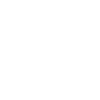

In [ ]:
df["geometry"][9]

Explorando o cadastro. As colunas de controle da paginação do WFS não fazem parte do imóvel.

In [ ]:
imoveis = df.drop(columns=[
    "total_features", "number_matched", "number_returned",
    "start_index", "page", "remaining", "is_pagination",
])
imoveis.info()

In [ ]:
imoveis["area"].describe().round(2)

Área fortemente assimétrica: muitos imóveis pequenos, poucos grandes — daí o eixo em log.

In [ ]:
import matplotlib.pyplot as plt

eixo = imoveis["area"].plot.hist(bins=50, log=True, figsize=(8, 4), edgecolor="white")
eixo.set_xlabel("área do imóvel (ha)")
eixo.set_ylabel("nº de imóveis (log)")
plt.show()

In [ ]:
imoveis["municipio"].value_counts().head(10)

A geometria é o que permite ligar imóvel e alerta (US-04).

In [ ]:
eixo = imoveis.plot(figsize=(8, 8), edgecolor="black", linewidth=0.2, alpha=0.7)
eixo.set_title(f"{len(imoveis)} imóveis do CAR em SC")
eixo.set_axis_off()
plt.show()

# MapBiomas

In [ ]:
import os
import json
import pandas as pd
from dotenv import load_dotenv

!wget -q https://raw.githubusercontent.com/Pedrinhonitz/planejamento-gestao-projetos/refs/heads/main/notebooks/hooks/http_mapbiomas_alerts_hook.py

from http_mapbiomas_alerts_hook import HttpMapbiomasAlertsHook

In [ ]:
pd.options.display.max_columns = 500

In [ ]:
from google.colab import userdata

load_dotenv()


hook = HttpMapbiomasAlertsHook(
    username=userdata.get("MAPBIOMAS_USERNAME"),
    password=userdata.get("MAPBIOMAS_PASSWORD"),
)

In [ ]:
result = hook.get_alerts_by_car("BA-2917359-8F7A81A691FA4256ACE671E7F9573C65")

In [ ]:
df = pd.DataFrame([result])

In [ ]:
df

,property,alerts
0,{'propertyCode': 'BA-2917359-8F7A81A691FA4256A...,"[{'alertCode': 875167, 'areaHa': 3417.1229, 'd..."


In [ ]:
df = df.explode("alerts")

In [ ]:
df

,property,alerts
0,{'propertyCode': 'BA-2917359-8F7A81A691FA4256A...,"{'alertCode': 875167, 'areaHa': 3417.1229, 'de..."


In [ ]:
dft = pd.json_normalize(
    data=json.loads(df.to_json(orient="records")),
    max_level=None,
    sep="_"
)

In [ ]:
dft["alerts_publishedImages"][0]

[{'url': 'https://image.alerta.mapbiomas.org/image/alert/876655/before_deforestation.png',
  'acquiredAt': '2022-10-11T12:55:06Z',
  'satellite': '2499'},
 {'url': 'https://image.alerta.mapbiomas.org/image/alert/876655/after_deforestation.png',
  'acquiredAt': '2023-04-25T12:26:11Z',
  'satellite': '24d0'}]

In [ ]:
dft

,property_propertyCode,property_carType,property_areaHa,property_state,property_stateAcronym,property_version,property_carUpdatedAt,property_insertedAt,property_boundingBox,alerts_alertCode,alerts_areaHa,alerts_detectedAt,alerts_publishedAt,alerts_sources,alerts_statusName,alerts_boundingBox_neLat,alerts_boundingBox_neLng,alerts_boundingBox_swLat,alerts_boundingBox_swLng,alerts_coordenates_latitude,alerts_coordenates_longitude,alerts_imageAcquiredBeforeAt,alerts_imageAcquiredAfterAt,alerts_publishedImages
0,BA-2917359-8F7A81A691FA4256ACE671E7F9573C65,SICAR_IRU,1586.68314,BA,BA,4,2025-09-27,2025-09-27T13:52:48Z,"[-45.35392951, -13.940652005, -45.29812303, -1...",875167,3417.1229,2023-01-01,2023-08-01,"[DETER-CERRADO, SAD-CERRADO]",published,-45.246291,-13.841017,-45.353537,-13.948263,-13.895919,-45.314625,2022-10-11,2023-04-25,[{'url': 'https://image.alerta.mapbiomas.org/i...


Os campos que viram atributos do modelo: área do alerta, área do imóvel, datas e localização.

In [ ]:
dft[[
    "property_propertyCode", "property_areaHa", "property_state",
    "alerts_alertCode", "alerts_areaHa", "alerts_detectedAt", "alerts_publishedAt",
    "alerts_sources", "alerts_statusName",
    "alerts_coordenates_latitude", "alerts_coordenates_longitude",
]].T

# Priorização

O `ml/pipeline.py` do repositório transforma os alertas em uma lista ranqueada e
explicável (US-01 e US-06).

> A célula abaixo baixa o pipeline do branch `main` — depende do merge do
> `feat/adding-ml-pipeline`.

In [ ]:
# O pipeline é um pacote: baixar para ml/ faz ele resolver os caminhos de data/.
!mkdir -p ml && touch ml/__init__.py
!wget -q -O ml/pipeline.py https://raw.githubusercontent.com/Pedrinhonitz/planejamento-gestao-projetos/refs/heads/main/ml/pipeline.py

from ml.pipeline import (
    FEATURES, build_features, build_label, load_bundle, rank, sample_alerts,
    save_model, train,
)

Coletar alertas em escala exige credenciais e ainda não cruzamos as camadas de UC, TI
e embargo. A amostra sintética tem a mesma estrutura do dado real, com valores
fictícios — serve para ver o fluxo ponta a ponta.

In [ ]:
alertas = sample_alerts()
atributos = build_features(alertas)
atributos.describe().T.round(2)

Sem resultados de fiscalização coletados (US-09), o alvo vem de um **rótulo fraco**:
regras de gravidade legal. As métricas abaixo medem o modelo reproduzindo essas
regras, não acerto em campo.

In [ ]:
rotulo, origem = build_label(alertas, atributos)
modelo, metricas = train(atributos, rotulo)

print("origem do rótulo:", origem["tipo"])
metricas

In [ ]:
save_model(modelo, atributos, metricas, origem)
priorizados = rank(alertas, atributos, load_bundle(), top=10)
priorizados[["posicao", "municipality", "area_ha", "prioridade", "fatores"]]

Importância global dos atributos — a base da explicação de cada alerta (US-06).

In [ ]:
eixo = (
    pd.Series(modelo.feature_importances_, index=list(FEATURES))
    .sort_values()
    .plot.barh(figsize=(7, 4))
)
eixo.set_xlabel("importância")
plt.show()